# Illustration 7.5-2 and Table 7.5-2 &mdash; completing the oxygen properties chart

**Illustration 7.5-2** (*Completing the Construction of a Thermodynamic Properties Chart
Using an Equation of State*) is the last of the three-part sequence that began with
Illustration 6.4-1. Chapter 6 built the pressure&ndash;volume, pressure&ndash;enthalpy,
and temperature&ndash;entropy charts for oxygen from the Peng&ndash;Robinson equation of
state, but had to stop above the critical temperature. Illustration 7.5-1 supplied the
vapor pressure and the properties of the two coexisting phases
([`vapor_pressure_oxygen.ipynb`](vapor_pressure_oxygen.ipynb), **Table 7.5-1** and
**Figure 7.5-3**). This illustration uses that vapor pressure to fill in the
low-temperature part of the chart, from $-100\,^\circ$C down to $-200\,^\circ$C, and
generates **Table 7.5-2**.

**What is new here is one decision, made 52 times.** The arithmetic &mdash; solve the
cubic for $Z$, add the departure functions to the ideal-gas $\underline H$ and
$\underline S$ &mdash; is exactly Illustration 6.4-1. But below $T_c$ the cubic can
return *three* real roots at a given $(T,P)$, and the equation of state alone does not
say which one the fluid is in. The text gives the rule:

> If three solutions are obtained and the system pressure is above the vapor pressure,
> the liquid is the stable phase and the smallest compressibility (or specific volume)
> is the correct solution&hellip; Conversely, if the system pressure is below the
> calculated vapor pressure, the vapor is the stable phase and the largest
> compressibility or specific volume root is to be used.

That rule is why Chapter 6 could not finish the chart, and why the vapor pressure had to
be computed first. Below we apply it, and check it against the deeper criterion it comes
from ($\underline G$ minimum at fixed $T$ and $P$, Eq. 7.1-12).

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# The axis labels below use the book's molar underbar, \underline{V}. With no LaTeX
# installed, matplotlib renders math with its own mathtext engine, which only learned
# \underline in 3.11 -- and Colab still ships 3.10. This upgrades it there, and does
# nothing at all on a machine that already has 3.11 or newer.
#
# ON COLAB THIS NEEDS A SESSION RESTART. Colab imports matplotlib as the session
# starts, so pip can replace the files on disk but not the module already loaded in
# memory: without a restart the kernel keeps running 3.10 and the labels still fail.
# One click, once per session. The cell prints the instruction when it applies.
import sys
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("\n" + "=" * 72)
        print("  matplotlib was upgraded so this notebook can draw the book's notation.")
        print("  RESTART NOW:   Runtime > Restart session,   then Run all.")
        print("  Colab only, once per session. Without it the next figure will fail.")
        print("=" * 72 + "\n")
# ---------------------------------------------------------------------------

## Properties of oxygen

Identical to Illustration 7.5-1 &mdash; the same critical constants, acentric
factor, Appendix A.II ideal-gas heat capacity, and reference state
(the ideal gas at $25\,^\circ$C and 1 bar). They have to be identical: the numbers here
share a chart with the ones there.

> ⚠️ The $C_P^{*}$ coefficients below are the oxygen entry of **SIS Appendix A.II**, and
> *not* the Reid&ndash;Prausnitz&ndash;Poling set carried in
> `code/data/pure_property.csv`; over 73&ndash;298 K the two differ by up to 152 J/mol in
> $\underline H$ and 1.2 J/(mol&middot;K) in $\underline S$. Note also that this table
> runs down to 73 K, 200 K below the 273&ndash;1800 K range Appendix A.II quotes, so the
> ideal-gas part of $\underline H$ and $\underline S$ rests on an extrapolated
> correlation. The *departure* functions, which carry all of the real-fluid physics, are
> unaffected. Both points are discussed at greater length in
> [`vapor_pressure_oxygen.ipynb`](vapor_pressure_oxygen.ipynb).

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import constants
from scipy.optimize import brentq
from numpy.polynomial import Polynomial

# Typography, matching the other recomputed figures: use a real LaTeX installation when
# there is one, so anything plotted is set in Computer Modern like the book, and fall
# back to matplotlib's own mathtext otherwise — the notebook still runs in Colab, which
# has no TeX. The fallback keeps a serif face and CM math.
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})

R = constants.R      # gas constant, J/(mol K)
BAR = 1e5            # Pa per bar
TO_KELVIN = 273.15
SQRT2 = np.sqrt(2.0)

# oxygen — SIS Table 6.6-1
Tc = 154.6           # K
Pc = 5.046e6         # Pa
omega = 0.021        # acentric factor

# ideal-gas heat capacity, SIS Appendix A.II (J/(mol K); fitted 273-1800 K)
cA, cB, cC, cD = 25.460, 1.519e-2, -0.715e-5, 1.311e-9

# reference state of Illustration 6.4-1: the ideal gas at 25 C and 1 bar
T_REF, P_REF = 298.15, 1e5

kappa = 0.37464 + 1.54226 * omega - 0.26992 * omega**2
print(f"oxygen: Tc = {Tc} K ({Tc - TO_KELVIN:.2f} C), Pc = {Pc / BAR:.3f} bar, "
      f"omega = {omega}, kappa = {kappa:.4f}")
print(f"the four table temperatures, in kelvin: "
      f"{[round(t + TO_KELVIN, 2) for t in (-125, -150, -175, -200)]}")
print(f"all four are subcritical (Tr = "
      f"{', '.join(f'{(t + TO_KELVIN) / Tc:.2f}' for t in (-125, -150, -175, -200))}), "
      f"so three roots are possible at every one of them")

oxygen: Tc = 154.6 K (-118.55 C), Pc = 50.460 bar, omega = 0.021, kappa = 0.4069
the four table temperatures, in kelvin: [148.15, 123.15, 98.15, 73.15]
all four are subcritical (Tr = 0.96, 0.80, 0.63, 0.47), so three roots are possible at every one of them


## The equation of state and its departure functions

Unchanged from Illustration 6.4-1 and 7.5-1, and reproduced here so this notebook stands
on its own:

$$ P = \frac{RT}{\underline{V}-b} -
   \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)} \tag{Eq. 6.4-2}$$

$$ b = 0.07780\,\frac{RT_c}{P_c}, \qquad
   a(T) = 0.45724\,\frac{R^{2}T_c^{2}}{P_c}\,\alpha(T), \qquad
   \sqrt{\alpha} = 1 + \kappa\left(1-\sqrt{T/T_c}\right) $$

$$ Z^{3} + (B-1)Z^{2} + (A - 3B^{2} - 2B)Z + (-AB + B^{2} + B^{3}) = 0,
   \qquad A = \frac{aP}{(RT)^{2}}, \quad B = \frac{bP}{RT} \tag{Table 6.4-3}$$

With $\Lambda(Z,B) = \ln\!\big[(Z+(1+\sqrt2)B)/(Z+(1-\sqrt2)B)\big]$,

$$ \underline H - \underline H^{IG} = RT(Z-1)
   + \frac{T\,\mathrm{d}a/\mathrm{d}T - a}{2\sqrt{2}\,b}\,\Lambda(Z,B) \tag{Eq. 6.4-29}$$

$$ \underline S - \underline S^{IG} = R\ln(Z-B)
   + \frac{\mathrm{d}a/\mathrm{d}T}{2\sqrt{2}\,b}\,\Lambda(Z,B) \tag{Eq. 6.4-30}$$

and the fugacity coefficient, needed only to locate the vapor pressure, is

$$ \ln\frac{f}{P} = (Z-1) - \ln(Z-B) - \frac{A}{2\sqrt{2}B}\,\Lambda(Z,B) \tag{Eq. 7.4-14}$$

The ideal-gas parts are measured from the reference state,

$$ \underline H^{IG}(T) = \int_{T_0}^{T} C_P^{*}\,\mathrm{d}T, \qquad
   \underline S^{IG}(T,P) = \int_{T_0}^{T} \frac{C_P^{*}}{T}\,\mathrm{d}T
   - R\ln\frac{P}{P_0} $$

In [2]:
def calc_b():
    return 0.07780 * R * Tc / Pc


def calc_a(T):
    return 0.45724 * R**2 * Tc**2 / Pc * (1 + kappa * (1 - np.sqrt(T / Tc)))**2


def calc_dadT(T):
    """da/dT — needed only by the enthalpy and entropy departures."""
    sqrtalpha = 1 + kappa * (1 - np.sqrt(T / Tc))
    return -0.45724 * R**2 * Tc**2 / Pc * kappa * sqrtalpha / np.sqrt(T * Tc)


def PR_pressure(V, T):
    a, b = calc_a(T), calc_b()
    return R * T / (V - b) - a / (V * (V + b) + b * (V - b))


def PR_Z(P, T):
    """Real compressibility roots (ascending), with A and B."""
    a, b = calc_a(T), calc_b()
    A, B = a * P / (R * T)**2, b * P / (R * T)
    roots = Polynomial([-A * B + B**2 + B**3, A - 3 * B**2 - 2 * B, -1 + B, 1]).roots()
    # tolerance scaled to root magnitude: near Tc the roots crowd together and pick up
    # tiny numerical imaginary parts that a fixed tolerance would reject
    keep = np.abs(roots.imag) < 1e-9 * np.maximum(1.0, np.abs(roots.real))
    return np.sort(roots.real[keep]), A, B


def log_term(Z, B):
    return np.log((Z + (1 + SQRT2) * B) / (Z + (1 - SQRT2) * B))


def PR_lnphi(Z, A, B):
    return (Z - 1) - np.log(Z - B) - A / (2 * SQRT2 * B) * log_term(Z, B)


def departure_H(T, Z, A, B):
    """H - H_ideal-gas at (T, P), J/mol (SIS Eq. 6.4-29)."""
    a, b, dadT = calc_a(T), calc_b(), calc_dadT(T)
    return R * T * (Z - 1) + (T * dadT - a) / (2 * SQRT2 * b) * log_term(Z, B)


def departure_S(T, Z, A, B):
    """S - S_ideal-gas at (T, P), J/(mol K) (SIS Eq. 6.4-30)."""
    b, dadT = calc_b(), calc_dadT(T)
    return R * np.log(Z - B) + dadT / (2 * SQRT2 * b) * log_term(Z, B)


def H_ideal(T):
    """Ideal-gas enthalpy relative to T_REF, J/mol."""
    return (cA * (T - T_REF) + cB / 2 * (T**2 - T_REF**2)
            + cC / 3 * (T**3 - T_REF**3) + cD / 4 * (T**4 - T_REF**4))


def S_ideal(T, P):
    """Ideal-gas entropy relative to (T_REF, P_REF), J/(mol K)."""
    return (cA * np.log(T / T_REF) + cB * (T - T_REF)
            + cC / 2 * (T**2 - T_REF**2) + cD / 3 * (T**3 - T_REF**3)
            - R * np.log(P / P_REF))


# Sanity check on the reference state: H and S are defined to be zero for the IDEAL gas
# at 25 C and 1 bar, and oxygen there is very nearly — but not quite — ideal. Both
# should therefore come out small, and their size is the departure of real oxygen from
# ideality at ambient conditions.
Z0, A0, B0 = PR_Z(P_REF, T_REF)
Z0 = Z0[Z0 > B0].max()
print(f"H(25 C, 1 bar) = {H_ideal(T_REF) + departure_H(T_REF, Z0, A0, B0):>8.2f} J/mol")
print(f"S(25 C, 1 bar) = {S_ideal(T_REF, P_REF) + departure_S(T_REF, Z0, A0, B0):>8.4f}"
      f" J/(mol K)")

H(25 C, 1 bar) =    -9.45 J/mol
S(25 C, 1 bar) =  -0.0240 J/(mol K)


## Step one: the vapor pressure

Nothing in the root-selection rule can be evaluated without $P^{\mathrm{vap}}(T)$, so the
saturation calculation of Illustration 7.5-1 comes first. It is the equal-fugacity
condition $f^{L} = f^{V}$ of Sec. 7.4 &mdash; the algorithm of the Fig. 7.5-1 flow sheet
&mdash; and the code is copied unchanged from
[`vapor_pressure_oxygen.ipynb`](vapor_pressure_oxygen.ipynb), including the device of
**bracketing** the root between the two spinodal pressures rather than guessing a
starting pressure, which is what makes the trivial solution unreachable.

Only four temperatures are needed, and every one of them is subcritical, so all four have
a vapor pressure.

In [3]:
def spinodal_bounds(T, n=20000):
    """Pressures at the local max and min of the sub-critical isotherm loop.
    Returns None once the loop has vanished (T >= Tc)."""
    b = calc_b()
    V = np.logspace(np.log10(1.0000001 * b), 3.0, n)
    P = PR_pressure(V, T)
    turns = np.where(np.diff(np.sign(np.diff(P))) != 0)[0]
    if len(turns) < 2:
        return None
    return P[turns].min(), P[turns].max()


def fugacity_residual(T, P):
    """ln(f_L/P) - ln(f_V/P); NaN if the cubic has no two distinct phase roots."""
    Z, A, B = PR_Z(P, T)
    Z = Z[Z > B]
    if len(Z) < 2:
        return np.nan
    return PR_lnphi(Z.min(), A, B) - PR_lnphi(Z.max(), A, B)


def Psat(T):
    """Vapor pressure (Pa) at T (K), bracketed between the spinodals."""
    bounds = spinodal_bounds(T)
    if bounds is None:
        return None
    P_lo, P_hi = bounds
    P_lo = max(P_lo, 1e-10 * BAR)          # the vapor spinodal pressure can be negative
    for _ in range(200):
        r_lo, r_hi = fugacity_residual(T, P_lo), fugacity_residual(T, P_hi)
        if np.isfinite(r_lo) and np.isfinite(r_hi) and r_lo * r_hi < 0:
            break
        if not np.isfinite(r_lo):
            P_lo *= 1.5
        if not np.isfinite(r_hi):
            P_hi *= 0.999
        if P_hi <= P_lo:
            return None
    else:
        return None
    return brentq(lambda P: fugacity_residual(T, P), P_lo, P_hi,
                  xtol=1e-12, rtol=1e-12)


T_TABLE_C = [-125, -150, -175, -200]
PVAP = {tC: Psat(tC + TO_KELVIN) for tC in T_TABLE_C}

print("vapor pressures at the four table temperatures\n"
      "(these are the Table 7.5-1 entries, recomputed here so this notebook is\n"
      " self-contained):\n")
print(f"{'T (C)':>7}{'T (K)':>9}{'Pvap (bar)':>13}")
for tC in T_TABLE_C:
    print(f"{tC:>7}{tC + TO_KELVIN:9.2f}{PVAP[tC] / BAR:13.3f}")

vapor pressures at the four table temperatures
(these are the Table 7.5-1 entries, recomputed here so this notebook is
 self-contained):

  T (C)    T (K)   Pvap (bar)
   -125   148.15       39.417
   -150   123.15       12.291
   -175    98.15        2.193
   -200    73.15        0.113


## Step two: the rule for choosing a root

At each $(T,P)$ the cubic in $Z$ has either one real root or three. One root is no
choice at all: the fluid is whatever that root says it is. Three roots is the case the
illustration is about, and the rule is

$$ P > P^{\mathrm{vap}}(T) \;\Longrightarrow\; \text{liquid, take } Z_{\min}, \qquad
   P < P^{\mathrm{vap}}(T) \;\Longrightarrow\; \text{vapor, take } Z_{\max} $$

The middle root is never used. It lies on the branch where
$(\partial P/\partial \underline V)_T > 0$, which violates the mechanical stability
criterion of Eq. 7.2-13; it is not a physically realizable state under any
circumstances.

**Where the rule comes from.** It is not a separate postulate. At fixed $T$ and $P$ the
stable state is the one of lowest molar Gibbs energy (Eq. 7.1-12), and
$\underline G = \underline H - T\underline S$ is something we can evaluate for each root
from quantities we already have. The vapor-pressure rule is the *cheap* form of that
test: $P^{\mathrm{vap}}$ is by construction the single pressure at which the two roots
have equal $\underline G$ (equivalently, equal fugacity), so which side of
$P^{\mathrm{vap}}$ the system sits on decides which root wins. We compute both and check
them against each other further down.

`state` below returns everything one cell of the table needs, and records how many roots
it had to choose from.

In [4]:
def state(T, P):
    """Thermodynamic properties of the stable phase at (T, P).

    V is in m^3/kmol (= L/mol), H in J/mol, S in J/(mol K), G in J/mol.
    `phase` is L or V; `nroots` is how many real roots the cubic offered."""
    Z, A, B = PR_Z(P, T)
    Z = Z[Z > B]                       # a root below B is not physical
    Pvap = Psat(T)                     # None above Tc; all four table temperatures are below
    liquid = Pvap is not None and P > Pvap
    Zx = Z.min() if (liquid and len(Z) > 1) else Z.max() if len(Z) > 1 else Z[0]

    H = H_ideal(T) + departure_H(T, Zx, A, B)
    S = S_ideal(T, P) + departure_S(T, Zx, A, B)
    return {"Z": Zx, "V": Zx * R * T / P * 1e3, "H": H, "S": S, "G": H - T * S,
            "phase": "L" if liquid else "V", "nroots": len(Z)}


# spot check: the two sides of the vapor pressure at -175 C (Pvap = 2.19 bar)
for P_bar in (2, 5):
    s = state(-175 + TO_KELVIN, P_bar * BAR)
    print(f"-175 C, {P_bar:>3} bar:  {s['nroots']} roots, "
          f"stable phase {s['phase']}, Z = {s['Z']:.4f}, "
          f"V = {s['V']:.4f} m3/kmol")

-175 C,   2 bar:  3 roots, stable phase V, Z = 0.9502, V = 3.8772 m3/kmol
-175 C,   5 bar:  3 roots, stable phase L, Z = 0.0158, V = 0.0258 m3/kmol


## Table 7.5-2

Thirteen pressures from 1 to 100 bar against the four temperatures $-125$, $-150$,
$-175$, and $-200\,^\circ$C, giving $Z$, $\underline V$, $\underline H$, and
$\underline S$ in each cell &mdash; 52 states, 208 numbers. Volumes are in m$^3$/kmol
(= L/mol), enthalpies in J/mol, entropies in J/(mol&middot;K).

The printed table gives no indication of which phase each entry is; the phase grid
printed first below makes it explicit, and the staircase in it is the vapor-pressure
curve cutting through the table.

In [5]:
P_TABLE_BAR = [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

records = {(P, tC): state(tC + TO_KELVIN, P * BAR)
           for P in P_TABLE_BAR for tC in T_TABLE_C}


def grid(key, fmt):
    """One property as a pressure-by-temperature table, formatted like the book."""
    df = pd.DataFrame({tC: [records[(P, tC)][key] for P in P_TABLE_BAR]
                       for tC in T_TABLE_C}, index=P_TABLE_BAR)
    df.index.name = "P (bar)"
    df.columns = [f"{tC} C" for tC in T_TABLE_C]
    return df.to_string(formatters={c: fmt.format for c in df.columns})


print("phase of the stable root  (n = number of real roots the cubic offered)")
print(pd.DataFrame(
    {f"{tC} C": [f"{records[(P, tC)]['phase']}{records[(P, tC)]['nroots']}"
                 for P in P_TABLE_BAR] for tC in T_TABLE_C},
    index=pd.Index(P_TABLE_BAR, name="P (bar)")).to_string())

for key, label, fmt in (("Z", "Z", "{:.4f}"),
                        ("V", "V  (m3/kmol)", "{:.4f}"),
                        ("H", "H  (J/mol)", "{:.2f}"),
                        ("S", "S  (J/mol K)", "{:.2f}")):
    print(f"\n{label}")
    print(grid(key, fmt))

phase of the stable root  (n = number of real roots the cubic offered)
        -125 C -150 C -175 C -200 C
P (bar)                            
1           V1     V3     V3     L3
2           V1     V3     V3     L3
5           V1     V3     L3     L3
10          V1     V3     L3     L1
20          V1     L3     L1     L1
30          V1     L1     L1     L1
40          L3     L1     L1     L1
50          L1     L1     L1     L1
60          L1     L1     L1     L1
70          L1     L1     L1     L1
80          L1     L1     L1     L1
90          L1     L1     L1     L1
100         L1     L1     L1     L1

Z
        -125 C -150 C -175 C -200 C
P (bar)                            
1       0.9915 0.9863 0.9756 0.0038
2       0.9830 0.9722 0.9502 0.0076
5       0.9569 0.9285 0.0158 0.0191
10      0.9116 0.8478 0.0316 0.0382
20      0.8118 0.0598 0.0630 0.0762
30      0.6911 0.0889 0.0943 0.1142
40      0.1512 0.1176 0.1254 0.1521
50      0.1740 0.1458 0.1563 0.1900
60      0.1987 0.1737 0.18

## How often does the choice actually matter?

Less often than the illustration's emphasis suggests, and that is worth seeing. Of the 52
states, only **13** present three roots at all; at the other 39 the cubic returns a single
root and there is nothing to decide. The three-root cells cluster where they must: near
the vapor pressure, in a band that walks up and to the right as the temperature rises,
because $P^{\mathrm{vap}}$ rises with $T$.

The table below lists every three-root state, and for each one puts the two rules side by
side: the illustration's ($P$ against $P^{\mathrm{vap}}$) and the criterion it descends
from ($\underline G$ minimum at fixed $T,P$). They agree in all 13 cases, as they must
&mdash; but seeing $\underline G^{L}$ and $\underline G^{V}$ cross exactly at
$P^{\mathrm{vap}}$ is what makes the rule something other than a recipe.

The last column is worth a moment. It is the enthalpy the *rejected* root would have
given, and the gap between it and the accepted value runs to thousands of joules per
mole. Choosing the wrong root does not produce a slightly wrong answer.

In [6]:
rows = []
for tC in T_TABLE_C:
    T = tC + TO_KELVIN
    for P_bar in P_TABLE_BAR:
        P = P_bar * BAR
        Z, A, B = PR_Z(P, T)
        Z = Z[Z > B]
        if len(Z) < 2:
            continue
        G, H = {}, {}
        for tag, Zx in (("L", Z.min()), ("V", Z.max())):
            H[tag] = H_ideal(T) + departure_H(T, Zx, A, B)
            S = S_ideal(T, P) + departure_S(T, Zx, A, B)
            G[tag] = H[tag] - T * S
        keep = "L" if P > PVAP[tC] else "V"          # the illustration's rule
        lower = "L" if G["L"] < G["V"] else "V"      # G minimum, Eq. 7.1-12
        rows.append({"T (C)": tC, "P (bar)": P_bar, "Pvap (bar)": PVAP[tC] / BAR,
                     "G liq": G["L"], "G vap": G["V"],
                     "Pvap rule": keep, "G min": lower,
                     "agree": "yes" if keep == lower else "NO",
                     "H rejected - H kept": H["V" if keep == "L" else "L"] - H[keep]})

three_root = pd.DataFrame(rows)
print(f"{len(three_root)} of {len(records)} states have three real roots\n")
print(three_root.to_string(index=False, formatters={
    "T (C)": "{:.0f}".format, "P (bar)": "{:.0f}".format,
    "Pvap (bar)": "{:.3f}".format, "G liq": "{:.1f}".format,
    "G vap": "{:.1f}".format, "H rejected - H kept": "{:+.0f}".format}))

print(f"\nthe two criteria agree in {(three_root['agree'] == 'yes').sum()} of "
      f"{len(three_root)} cases")
print(f"picking the wrong root would move H by up to "
      f"{three_root['H rejected - H kept'].abs().max():.0f} J/mol")

13 of 52 states have three real roots

T (C) P (bar) Pvap (bar)   G liq   G vap Pvap rule G min agree H rejected - H kept
 -125      40     39.417  2728.1  2734.6         L     L   yes               +2619
 -150       1     12.291   459.9 -1904.7         V     V   yes               -5824
 -150       2     12.291   463.0 -1209.2         V     V   yes               -5788
 -150       5     12.291   472.4  -314.2         V     V   yes               -5676
 -150      10     12.291   487.9   320.1         V     V   yes               -5465
 -150      20     12.291   518.7   858.3         L     L   yes               +4829
 -175       1      2.193 -1993.6 -2607.3         V     V   yes               -6579
 -175       2      2.193 -1991.0 -2061.8         V     V   yes               -6527
 -175       5      2.193 -1983.3 -1377.1         L     L   yes               +6354
 -175      10      2.193 -1970.4  -930.9         L     L   yes               +5945
 -200       1      0.113 -4783.4 -3487.5        

## Where these states sit on the chart

The illustration ends by noting that the Table 7.5-2 values "also appear in Figs. 6.4-3,
6.4-4, and 6.4-5" &mdash; they are not a separate result but the low-temperature corner
of the charts built in Chapter 6. The plot below puts them there, in the
pressure&ndash;enthalpy plane of Fig. 6.4-4:

- the **dome** is the two-phase envelope, $\underline H^{L}$ and $\underline H^{V}$ along
  the saturation line &mdash; that is Table 7.5-1, drawn;
- the **curves** are the four isotherms of this table, computed on a fine pressure grid
  with the same root-selection rule;
- the **markers** are the 52 tabulated states.

The isotherms are drawn from 0.05 bar so that the jump is visible at all four
temperatures; the table itself starts at 1 bar, which is already above
$P^{\mathrm{vap}}$ at $-200\,^\circ$C.

*This is not a printed figure* &mdash; Illustration 7.5-2 has no figure of its own. It is
here to connect the table to the charts it belongs to, so no PDF is written and it
carries no QR key.

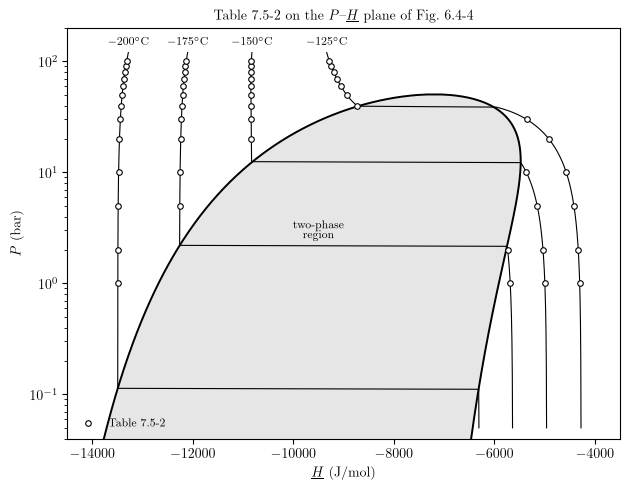

In [7]:
BLACK = "black"
fig, ax = plt.subplots(figsize=(6.4, 5.0))

# --- the two-phase envelope: Table 7.5-1, computed on a fine temperature grid ---
T_dome = np.linspace(65.0, 0.9995 * Tc, 300)
HL, HV, P_dome = [], [], []
for T in T_dome:
    P = Psat(T)
    if P is None:
        continue
    Z, A, B = PR_Z(P, T)
    Z = Z[Z > B]
    if len(Z) < 2:
        continue
    HL.append(H_ideal(T) + departure_H(T, Z.min(), A, B))
    HV.append(H_ideal(T) + departure_H(T, Z.max(), A, B))
    P_dome.append(P / BAR)

ax.plot(np.r_[HL, HV[::-1]], np.r_[P_dome, P_dome[::-1]], "-", color=BLACK, lw=1.4)
ax.fill(np.r_[HL, HV[::-1]], np.r_[P_dome, P_dome[::-1]], color="0.90", zorder=0)

# --- the four isotherms, on a fine pressure grid, using the same selection rule ---
P_fine = np.logspace(np.log10(0.05), np.log10(120), 400) * BAR
for tC in T_TABLE_C:
    T = tC + TO_KELVIN
    H_line = np.array([state(T, P)["H"] for P in P_fine])
    ax.plot(H_line, P_fine / BAR, "-", color=BLACK, lw=0.8)
    # Label each isotherm just above its high-pressure end, in the headroom left between
    # the top of the curves (120 bar) and the top of the frame. The liquid branches are
    # ~1500 J/mol apart there; at the low-pressure end they crowd together.
    ax.annotate(rf"${tC}^\circ$C", xy=(H_line[-1], P_fine[-1] / BAR),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=8)

# --- the 52 tabulated states ---
ax.plot([records[k]["H"] for k in records], [k[0] for k in records],
        "o", mfc="white", mec=BLACK, ms=4, mew=0.8, zorder=3,
        label="Table 7.5-2")

ax.set_yscale("log")
ax.set_xlim(-14500, -3500)
ax.set_ylim(0.04, 200)
ax.set_xlabel(r"$\underline{H}$  (J/mol)")
ax.set_ylabel(r"$P$  (bar)")
ax.set_title(r"Table 7.5-2 on the $P$--$\underline{H}$ plane of Fig.\ 6.4-4"
             if mpl.rcParams["text.usetex"] else
             r"Table 7.5-2 on the $P$-$\underline{H}$ plane of Fig. 6.4-4",
             fontsize=10)
ax.annotate("two-phase\nregion", xy=(-9500, 3), ha="center", va="center", fontsize=8)
ax.legend(loc="lower left", frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## What the table shows

**The chart is now closed.** Chapter 6 could compute $\underline V$, $\underline H$, and
$\underline S$ anywhere the cubic gave one root, which meant everywhere above $T_c$ and
in the far corners below it &mdash; but not in the band around the vapor pressure, which
is precisely the region an engineer cares about. Illustration 7.5-1 supplied
$P^{\mathrm{vap}}(T)$, this illustration spends it, and the low-temperature corner is
filled in. The three illustrations are one calculation in three stages.

**The isotherms are nearly vertical in the liquid.** Read down the $-200\,^\circ$C column:
from 1 to 100 bar, a hundredfold change in pressure, $\underline V$ falls only from
0.0232 to 0.0230 m$^3$/kmol and $\underline H$ rises by about 174 J/mol. Liquids are
nearly incompressible, and that is the fact behind the Poynting correction of Eq. 7.4-18
and behind treating $\underline V^{L}$ as constant in the Clapeyron equation.

**The jump across the dome is the enthalpy of vaporization.** At $-125\,^\circ$C,
$\underline H$ falls from $-5357$ J/mol at 30 bar to $-8735$ J/mol at 40 bar. Nothing has
happened to the fluid between those two pressures except that it crossed
$P^{\mathrm{vap}} = 39.4$ bar and condensed; the 3378 J/mol is
$\Delta^{\mathrm{vap}}\underline H$ at 148 K, give or take the small pressure corrections
on either side of the saturation line. The corresponding jump at $-200\,^\circ$C, read
straight off Table 7.5-1, is 7182 J/mol &mdash; more than twice as large, because
$\Delta^{\mathrm{vap}}\underline H$ must vanish at $T_c$ and $-125\,^\circ$C is only
6.5 K below it.

**And a caution the book states plainly.** All of this came from a three-parameter
($T_c$, $P_c$, $\omega$) cubic equation of state. The results are good estimates, not
reference-quality data: the steam tables of Appendix A.III rest on an equation with 59
substance-specific constants, fitted to a very large body of careful measurement. The
Peng&ndash;Robinson generalization is useful for hydrocarbons and inorganic gases like
oxygen; for polar fluids it is not accurate at low temperature and pressure, which is
what motivates the Stryjek&ndash;Vera modification (Eqs. 7.5-1 and 7.5-2) at the end of
the section.

### Things to try

1. **Watch the two criteria cross.** At $-150\,^\circ$C, plot $\underline G^{L}$ and
   $\underline G^{V}$ against pressure from 5 to 20 bar. They should intersect at
   $P^{\mathrm{vap}} = 12.29$ bar. Which branch is lower on each side, and does that
   reproduce the rule?
2. **Find the three-root band.** Map, over a fine grid in $T$ and $P$, where the cubic
   has three real roots, and overlay $P^{\mathrm{vap}}(T)$ and the two spinodals. The
   band is bounded by the spinodals, not by the vapor pressure &mdash; which is why
   metastable states (superheated liquid, subcooled vapor) exist at all.
3. **Use the wrong root deliberately.** Redo the table taking $Z_{\max}$ everywhere and
   plot the result on the $P$&ndash;$\underline H$ axes above. The isotherms will run
   straight through the two-phase region into the superheated-vapor branch: they are the
   metastable and unstable continuations, and they are what Fig. 7.3-3 draws.
4. **Change the substance.** Problems 7.33 and 7.34 ask for exactly these tables and
   charts for nitrogen and for water. Nitrogen behaves; water, being polar, is where the
   generalized $\kappa(\omega)$ correlation starts to fail. Compare the water results
   against Appendix A.III and see how large the error is.
5. **Change the equation of state.** Problem 7.52 asks for this illustration with the
   Soave&ndash;Redlich&ndash;Kwong equation. Only `PR_Z`, the cubic coefficients, and the
   two departure functions change; everything downstream &mdash; the saturation solver,
   the root-selection rule, the table &mdash; is untouched.